# TD4 — Feature engineering EEG pour l'estimation de la charge cognitive

## Contexte

Ce TD s'inscrit dans le projet fil rouge basé sur le papier :

**Multimodal Brain-Computer Interface for In-Vehicle Driver Cognitive Load Measurement: Dataset and Baselines**.

Le papier introduit le dataset **CL-Drive**, dans lequel des signaux EEG, ECG, EDA et Gaze sont enregistrés pendant une tâche de conduite simulée. Les scores de charge cognitive sont collectés toutes les **10 secondes**. Après prétraitement, les signaux sont segmentés en fenêtres de 10 s, puis transformés en caractéristiques numériques pour entraîner des modèles de classification.

Dans ce TD, on se concentre uniquement sur les **features EEG**.

---

## Objectifs pédagogiques

À la fin du TD, vous devez être capables de :

1. expliquer pourquoi on transforme un signal EEG en vecteur de caractéristiques ;
2. distinguer les features temporelles, fréquentielles et non linéaires ;
3. expliquer le principe de la densité spectrale de puissance, ou PSD ;
4. calculer des puissances par bande EEG ;
5. interpréter l'entropie spectrale ;
6. expliquer les paramètres de Hjorth ;
7. comprendre le principe de la complexité de Lempel-Ziv ;
8. comprendre l'idée de la dimension fractale de Higuchi ;
9. structurer une fonction complète d'extraction de features EEG ;
10. préparer une matrice de features pour la classification.

---

## Features EEG ciblées

Le papier regroupe les features EEG suivantes :

| Famille | Features |
|---|---|
| PSD | puissance absolue, moyenne, maximale, minimale et médiane |
| Entropie spectrale | entropie calculée à partir de la PSD normalisée |
| Hjorth | mobility et complexity |
| Lempel-Ziv | complexité d'une séquence binarisée |
| Higuchi | dimension fractale |
| Statistiques temporelles | moyenne, minimum, maximum, médiane, variance, écart-type |

Dans ce TD, on adopte une version complète :

- PSD calculée dans les cinq bandes EEG : delta, theta, alpha, beta, gamma ;
- entropie spectrale calculée dans les cinq bandes ;
- features non linéaires calculées sur le segment temporel ;
- statistiques temporelles calculées sur le segment.

On obtient donc :

$$
5 \text{ bandes} \times 5 \text{ descripteurs PSD} = 25
$$

$$
5 \text{ entropies spectrales} = 5
$$

$$
2 \text{ Hjorth} + 1 \text{ Lempel-Ziv} + 1 \text{ Higuchi} + 6 \text{ statistiques} = 10
$$

Soit au total :

$$
25 + 5 + 10 = 40 \text{ features par canal EEG}
$$

In [ ]:
!unzip -o /content/preprocessedData.zip -d /content/Data

Archive:  /content/preprocessedData.zip
   creating: /content/Data/EEG/
   creating: /content/Data/Labels/
   creating: /content/Data/EEG/1030/
   creating: /content/Data/EEG/1105/
   creating: /content/Data/EEG/1106/
   creating: /content/Data/EEG/1241/
   creating: /content/Data/EEG/1271/
   creating: /content/Data/EEG/1314/
   creating: /content/Data/EEG/1323/
   creating: /content/Data/EEG/1337/
   creating: /content/Data/EEG/1372/
   creating: /content/Data/EEG/1417/
   creating: /content/Data/EEG/1434/
   creating: /content/Data/EEG/1544/
   creating: /content/Data/EEG/1547/
   creating: /content/Data/EEG/1595/
   creating: /content/Data/EEG/1629/
   creating: /content/Data/EEG/1716/
   creating: /content/Data/EEG/1717/
   creating: /content/Data/EEG/1744/
   creating: /content/Data/EEG/1868/
   creating: /content/Data/EEG/1892/
   creating: /content/Data/EEG/1953/
   creating: /content/Data/EEG/1717/processed_eeg/
  inflating: /content/Data/EEG/1717/eeg_data_level_1.csv  
  infl

## Questions de compréhension

### Question 1

Pourquoi ne donne-t-on pas directement le signal EEG brut à un classifieur classique comme LDA, SVM ou Random Forest ?

### Réponse

On ne donne pas le signal brut car il est trop grand et bruité.

### Question 2

Pourquoi les features fréquentielles sont-elles particulièrement importantes en EEG ?

### Réponse

Les features fréquentielles sont importantes car les bandes EEG donnent des informations sur l’activité du cerveau.

### Question 3

Pourquoi faut-il calculer les features séparément sur chaque canal EEG ?

### Réponse

Chaque canal mesure une zone différente du cerveau.

## 1. Bandes fréquentielles EEG

Les signaux EEG sont souvent analysés par bandes de fréquence.

| Bande | Intervalle utilisé dans ce TD | Interprétation générale |
|---|---:|---|
| Delta | 0.5–4 Hz | activité lente |
| Theta | 4–8 Hz | attention, mémoire de travail, somnolence selon contexte |
| Alpha | 8–12 Hz | relaxation, inhibition, yeux fermés |
| Beta | 12–30 Hz | activité mentale, attention, activité motrice |
| Gamma | 30–75 Hz | activité rapide, intégration, mais sensible aux artefacts musculaires |

Dans le papier, la bande gamma va jusqu'à 75 Hz.

### Question 4

Pourquoi peut-on limiter la bande gamma à 45 Hz dans certaines implémentations ?

### Réponse

La bande Alpha doit dominer pour un signal à 10 Hz.

## 2. Méthodologie d'implémentation

Dans ce TD, l'objectif est de comprendre puis implémenter les fonctions essentielles.

Pour chaque fonction, vous aurez :

- une explication théorique ;
- l'algorithme ;
- les fonctions Python recommandées ;
- les paramètres importants ;
- des questions de vérification.

Les bibliothèques utiles sont :

| Objectif | Bibliothèque | Fonctions utiles |
|---|---|---|
| Tableaux numériques | NumPy | `np.array`, `np.mean`, `np.var`, `np.diff`, `np.median` |
| Données tabulaires | pandas | `pd.DataFrame`, `pd.read_csv`, `to_csv` |
| PSD | scipy.signal | `welch` |
| Entropie | scipy.stats | `entropy` |
| Visualisation | matplotlib | `plt.plot`, `plt.semilogy`, `plt.bar` |

### Travail à réaliser

Vous devez construire progressivement les fonctions suivantes :

1. `compute_psd_band_features(signal, fs)` ;
2. `compute_spectral_entropy_bands(signal, fs)` ;
3. `compute_hjorth(signal)` ;
4. `lempel_ziv_complexity(signal)` ;
5. `higuchi_fd(signal, kmax=10)` ;
6. `compute_raw_features(signal)` ;
7. `extract_eeg_features(signal, fs)` ;
8. une boucle permettant d'extraire les features sur des fenêtres de 10 secondes.

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import entropy

FS = 256
WINDOW_SEC = 10
WINDOW_SAMPLES = FS * WINDOW_SEC

EEG_BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 31),
    "gamma": (31, 75),
}

print("Nombre d'échantillons par fenêtre :", WINDOW_SAMPLES)
print("Bandes EEG :", EEG_BANDS)

Nombre d'échantillons par fenêtre : 2560
Bandes EEG : {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12), 'beta': (12, 31), 'gamma': (31, 75)}


## 3. Exemples pédagogiques sur signaux connus

Avant d'appliquer les features à l'EEG réel, on commence par des signaux connus.

On va comparer :

1. une sinusoïde à 2 Hz, principalement dans la bande delta ;
2. une sinusoïde à 10 Hz, principalement dans la bande alpha ;
3. une sinusoïde à 20 Hz, principalement dans la bande beta ;
4. un bruit blanc, dont l'énergie est plus répartie ;
5. un mélange de plusieurs composantes.

### Objectif pédagogique

Vérifier que les features donnent des résultats cohérents :

- une sinusoïde pure doit avoir une PSD concentrée ;
- le bruit doit avoir une entropie spectrale plus élevée ;
- une sinusoïde alpha doit avoir une puissance alpha dominante.

In [ ]:


def generate_synthetic_signals(fs=FS, duration=10, random_state=0):
    rng = np.random.default_rng(random_state)
    t = np.arange(0, duration, 1/fs)
    signals = {
        "delta_2Hz": np.sin(2*np.pi*2*t),
        "alpha_10Hz": np.sin(2*np.pi*10*t),
        "beta_20Hz": np.sin(2*np.pi*20*t),
        "white_noise": rng.normal(0, 1, size=len(t)),
        "mixed": 0.8*np.sin(2*np.pi*6*t) + 0.5*np.sin(2*np.pi*10*t) + 0.2*rng.normal(0, 1, size=len(t)),
    }
    return t, signals

t, synthetic_signals = generate_synthetic_signals()

## 4. Feature PSD : densité spectrale de puissance

### Principe théorique

La **PSD**, ou densité spectrale de puissance, indique comment la puissance du signal est répartie selon la fréquence.

Pour un segment EEG $x[n]$, on estime la PSD avec la méthode de Welch. L'idée est de :

1. découper le signal en sous-fenêtres ;
2. calculer un spectre sur chaque sous-fenêtre ;
3. moyenner les spectres pour obtenir une estimation plus stable.

En Python, on utilise généralement :

```python
freqs, psd = scipy.signal.welch(signal, fs=fs, nperseg=...)
```

### Paramètres recommandés

- `fs=256` pour CL-Drive ;
- `nperseg=fs*2` pour une fenêtre Welch de 2 secondes ;
- si le segment est court, prendre `nperseg=min(len(signal), fs*2)` ;
- sélectionner ensuite les fréquences appartenant à une bande donnée à l’aide d’un masque booléen (utiliser le vecteur `freqs` retourné `scipy.signal.welch`).

### Features PSD pour chaque bande

Pour chaque bande EEG, calculer :

1. puissance absolue : somme de la PSD dans la bande ;
2. puissance moyenne ;
3. puissance maximale ;
4. puissance minimale ;
5. puissance médiane.

### Algorithme

1. calculer `freqs, psd` avec Welch ;

Pour chaque bande $[f_{min}, f_{max}]$ :

   
2. sélectionner les indices tels que $f_{min} \le f < f_{max}$ ;
3. extraire `band_psd` ;
4. calculer `sum`, `mean`, `max`, `min`, `median` ;
5. stocker les résultats dans un dictionnaire.

### Questions

1. Quelle bande doit dominer pour un signal sinusoïdal à 10 Hz ?



2. Pourquoi la PSD est-elle plus stable avec Welch qu'avec un simple spectre FFT ?



3. Que se passe-t-il si la bande sélectionnée ne contient aucune fréquence ?



### Réponses

1. La bande Alpha (8-12 Hz) doit dominer car 10 Hz appartient à cette bande.

2. Parce que la méthode de Welch découpe le signal en plusieurs parties et fait une moyenne des spectres, ce qui réduit les variations dues au bruit.

3. La puissance calculée sera très faible ou égale à zéro.

In [ ]:

def compute_welch_psd(signal, fs):

    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=min(len(signal), fs * 2)
    )

    return freqs, psd


def compute_psd_band_features(signal, fs):

    psd_features = {}


    freqs, psd = compute_welch_psd(signal, fs)


    for band_name, (fmin, fmax) in EEG_BANDS.items():


        mask = (freqs >= fmin) & (freqs < fmax)

        band_psd = psd[mask]


        if len(band_psd) == 0:

            psd_features[f"{band_name}_absolute_power"] = 0
            psd_features[f"{band_name}_mean_power"] = 0
            psd_features[f"{band_name}_max_power"] = 0
            psd_features[f"{band_name}_min_power"] = 0
            psd_features[f"{band_name}_median_power"] = 0

            continue


        psd_features[f"{band_name}_absolute_power"] = np.sum(band_psd)

        psd_features[f"{band_name}_mean_power"] = np.mean(band_psd)

        psd_features[f"{band_name}_max_power"] = np.max(band_psd)

        psd_features[f"{band_name}_min_power"] = np.min(band_psd)

        psd_features[f"{band_name}_median_power"] = np.median(band_psd)

    return psd_features


signal = synthetic_signals["alpha_10Hz"]

psd_features = compute_psd_band_features(signal, FS)

print(psd_features)

{'delta_absolute_power': np.float64(4.787724684192978e-29), 'delta_mean_power': np.float64(6.839606691704254e-30), 'delta_max_power': np.float64(2.0265794026404318e-29), 'delta_min_power': np.float64(3.784459381889057e-31), 'delta_median_power': np.float64(2.7657760448696074e-30), 'theta_absolute_power': np.float64(1.734236938314812e-30), 'theta_mean_power': np.float64(2.167796172893515e-31), 'theta_max_power': np.float64(3.7042358520000413e-31), 'theta_min_power': np.float64(1.172100700865122e-31), 'theta_median_power': np.float64(2.0897567525765716e-31), 'alpha_absolute_power': np.float64(0.9999999999999996), 'alpha_mean_power': np.float64(0.12499999999999994), 'alpha_max_power': np.float64(0.6666666666666665), 'alpha_min_power': np.float64(9.105804398039887e-32), 'alpha_median_power': np.float64(2.6759921398143694e-31), 'beta_absolute_power': np.float64(7.337764267473245e-29), 'beta_mean_power': np.float64(1.9309905967034856e-30), 'beta_max_power': np.float64(2.0188667852888368e-29)

## 5. Entropie spectrale

### Principe théorique

L'entropie spectrale mesure la dispersion de l'énergie dans le domaine fréquentiel.

On calcule d'abord la PSD dans une bande, puis on la normalise pour obtenir une distribution :

$$
p_i = \frac{PSD_i}{\sum_j PSD_j}
$$

L'entropie de Shannon est ensuite :

$$
H = - \sum_i p_i \log(p_i)
$$


### Fonction Python utile

```python
from scipy.stats import entropy
```

`entropy(p)` calcule directement l'entropie de Shannon si `p` est une distribution normalisée.

### Questions

1. Pourquoi faut-il normaliser la PSD avant de calculer l'entropie ?
2. Quel signal devrait avoir l'entropie spectrale la plus élevée : une sinusoïde pure ou un bruit blanc ?
3. Pourquoi l'entropie spectrale peut-elle être utile pour caractériser la complexité d'un EEG ?

### Réponses

1. Parce que l'entropie utilise une distribution de probabilités dont la somme doit être égale à 1.

2. Le bruit blanc, car son énergie est répartie sur beaucoup de fréquences.

3. Parce qu'elle mesure à quel point l'énergie du signal est dispersée entre les différentes fréquences.

In [ ]:

def compute_spectral_entropy_bands(signal, fs):

    spectral_entropy_features = {}


    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=min(len(signal), fs * 2)
    )


    for band_name, (fmin, fmax) in EEG_BANDS.items():


        mask = (freqs >= fmin) & (freqs < fmax)

        band_psd = psd[mask]


        if len(band_psd) == 0 or np.sum(band_psd) == 0:
            spectral_entropy_features[f"{band_name}_spectral_entropy"] = 0
            continue


        p = band_psd / np.sum(band_psd)


        se = entropy(p)


        spectral_entropy_features[f"{band_name}_spectral_entropy"] = se

    return spectral_entropy_features

signal = synthetic_signals["white_noise"]

features_entropy = compute_spectral_entropy_bands(signal, FS)

print(features_entropy)

{'delta_spectral_entropy': np.float64(1.9115558202502687), 'theta_spectral_entropy': np.float64(2.045345787295431), 'alpha_spectral_entropy': np.float64(2.0310368027706174), 'beta_spectral_entropy': np.float64(3.581862087571888), 'gamma_spectral_entropy': np.float64(4.41698354276465)}


## 6. Paramètres de Hjorth : mobility et complexity

Les paramètres de Hjorth sont des descripteurs temporels utilisés pour caractériser la dynamique d'un signal.

### Mobility

La mobility mesure approximativement la fréquence moyenne du signal :

$$
Mobility(x) = \sqrt{\frac{Var(\Delta x)}{Var(x)}}
$$

où $\Delta x$ est la dérivée discrète du signal, généralement calculée avec `np.diff(x)`.

### Complexity

La complexity mesure la variation de la mobility entre le signal et sa dérivée :

$$
Complexity(x) = \frac{Mobility(\Delta x)}{Mobility(x)}
$$


### Questions

1. Que vaut approximativement la variance d'un signal constant ?
2. Pourquoi faut-il gérer le cas où `Var(x)=0` ?
3. Entre une sinusoïde lisse et un bruit blanc, lequel devrait avoir une complexity plus élevée ?

### Réponses

1. Elle vaut environ 0.

2. Pour éviter une division par zéro lors du calcul des indicateurs.

3. Le bruit blanc, car il est plus irrégulier.

In [ ]:

def compute_hjorth(signal):

    hjorth_features = {}


    dx = np.diff(signal)


    var_x = np.var(signal)
    var_dx = np.var(dx)


    if var_x == 0:
        mobility = 0
        complexity = 0
    else:

        mobility = np.sqrt(var_dx / var_x)


        ddx = np.diff(dx)

        var_ddx = np.var(ddx)


        if var_dx == 0:
            complexity = 0
        else:
            mobility_dx = np.sqrt(var_ddx / var_dx)


            complexity = mobility_dx / mobility


    hjorth_features["hjorth_mobility"] = mobility
    hjorth_features["hjorth_complexity"] = complexity

    return hjorth_features

signal = synthetic_signals["alpha_10Hz"]

hjorth = compute_hjorth(signal)

print(hjorth)

{'hjorth_mobility': np.float64(0.24477490737748014), 'hjorth_complexity': np.float64(1.0007474243958725)}


## 7. Complexité de Lempel-Ziv

### Principe théorique

La complexité de Lempel-Ziv mesure le nombre de motifs nouveaux rencontrés dans une séquence.

Comme l'algorithme s'applique à une séquence symbolique, un signal EEG réel doit d'abord être transformé en séquence binaire.

Une méthode simple consiste à binariser le signal par rapport à sa médiane :

$$
b[n] =
\begin{cases}
1, & x[n] > median(x) \\
0, & x[n] \le median(x)
\end{cases}
$$


### Paramètres importants

- seuil de binarisation : médiane ou moyenne ;
- normalisation de la complexité pour comparer des segments de même ou de différente longueur ;
- gestion des segments constants.

### Questions

1. Pourquoi faut-il binariser le signal avant de calculer Lempel-Ziv ?
2. Pourquoi la médiane est-elle un seuil intéressant ?
3. Quel signal devrait avoir une complexité plus élevée : une sinusoïde pure ou un bruit blanc ?
4. Pourquoi normaliser la complexité par la longueur de la séquence ?

### Réponses

1. Parce que l'algorithme travaille sur une suite de symboles binaires (0 et 1).

2. Parce qu'elle partage généralement les données en deux groupes équilibrés et elle est peu sensible aux valeurs extrêmes.

3. Le bruit blanc.

4. Pour pouvoir comparer des signaux de tailles différentes.

In [ ]:

def lempel_ziv_complexity(signal):


    signal = np.array(signal)


    median = np.median(signal)

    binary_signal = (signal > median).astype(int)


    s = ''.join(binary_signal.astype(str))

    n = len(s)


    if n == 0:
        return {"lempel_ziv_complexity": 0}


    i = 0
    complexity = 1
    sub_strings = set()

    while i < n - 1:

        for j in range(i + 1, n + 1):

            sub = s[i:j]

            if sub not in sub_strings:
                sub_strings.add(sub)
                complexity += 1
                break

        i += 1


    normalized_complexity = complexity / n

    return {
        "lempel_ziv_complexity": normalized_complexity
    }


signal = synthetic_signals["white_noise"]

lz_complexity = lempel_ziv_complexity(signal)

print(lz_complexity)

{'lempel_ziv_complexity': 0.99609375}


## 8. Dimension fractale de Higuchi

### Principe théorique

La dimension fractale de Higuchi cherche à mesurer la complexité géométrique d'un signal temporel.

Un signal très lisse ressemble davantage à une courbe régulière. Un signal très irrégulier ou bruité présente une trajectoire plus complexe.

L'algorithme de Higuchi construit plusieurs sous-séquences avec différents pas $k$, mesure leur longueur moyenne $L(k)$, puis estime une pente dans un espace logarithmique.

### Paramètre important

- `kmax` : pas maximal testé.

Pour un segment de 10 secondes à 256 Hz, une valeur pédagogique simple est :

```python
kmax = 10
```

Une valeur trop faible peut donner une estimation instable ; une valeur trop élevée augmente le coût de calcul.

### Questions

1. Que cherche à mesurer la dimension fractale de Higuchi ?
2. Pourquoi un signal bruité peut-il avoir une dimension fractale plus élevée qu'une sinusoïde ?
3. Quel est le rôle du paramètre `kmax` ?
4. Pourquoi faut-il éviter de calculer un logarithme de zéro ?

### Réponses

1. Elle mesure le degré de complexité ou d'irrégularité d'un signal.

2. Parce qu'il présente beaucoup plus de variations rapides et irrégulières.

3. Il détermine l'échelle maximale utilisée pour calculer la dimension fractale.

4. Parce que le logarithme de zéro n'est pas défini et provoque une erreur.

In [ ]:


def higuchi_fd(signal, kmax=10):

    signal = np.array(signal)

    N = len(signal)

    L = []
    k_values = []


    for k in range(1, kmax + 1):

        Lk = []


        for m in range(k):

            length = 0

            n_max = int((N - m - 1) / k)


            if n_max <= 1:
                continue

            for i in range(1, n_max):

                length += abs(
                    signal[m + i * k] - signal[m + (i - 1) * k]
                )


            length = (length * (N - 1)) / (n_max * k)

            Lk.append(length)


        if len(Lk) > 0:
            L_mean = np.mean(Lk)


            if L_mean > 0:
                L.append(np.log(L_mean))
                k_values.append(np.log(1 / k))


    if len(L) < 2:
        hfd = 0
    else:
        coeffs = np.polyfit(k_values, L, 1)
        hfd = coeffs[0]

    return {
        "higuchi_fd": hfd
    }

signal = synthetic_signals["white_noise"]

hfd = higuchi_fd(signal)

print(hfd)

{'higuchi_fd': np.float64(1.0007417924703712)}


## 9. Statistiques temporelles du signal brut

Les statistiques temporelles simples fournissent des informations directes sur l'amplitude et la variabilité du signal.

Features demandées :

1. moyenne ;
2. minimum ;
3. maximum ;
4. médiane ;
5. variance ;
6. écart-type.

### Fonctions Python utiles

| Feature | Fonction NumPy |
|---|---|
| moyenne | `np.mean` |
| minimum | `np.min` |
| maximum | `np.max` |
| médiane | `np.median` |
| variance | `np.var` |
| écart-type | `np.std` |


In [ ]:


def compute_raw_features(signal):

    signal = np.array(signal)

    raw_features = {

        "raw_mean": np.mean(signal),

        "raw_min": np.min(signal),

        "raw_max": np.max(signal),

        "raw_median": np.median(signal),

        "raw_variance": np.var(signal),

        "raw_std": np.std(signal),
    }

    return raw_features


signal = synthetic_signals["alpha_10Hz"]

raw_features = compute_raw_features(signal)

print(raw_features)

{'raw_mean': np.float64(3.400058012914542e-17), 'raw_min': np.float64(-1.0), 'raw_max': np.float64(1.0), 'raw_median': np.float64(-2.45548340466059e-16), 'raw_variance': np.float64(0.5), 'raw_std': np.float64(0.7071067811865476)}


## 10. Fonction complète d'extraction des 40 features EEG

À ce stade, on peut regrouper toutes les familles de features dans une seule fonction.

### Entrée

Un segment EEG 1D correspondant à :

- un canal ;
- une fenêtre de 10 secondes ;
- 2560 échantillons si `fs=256 Hz`.

### Sortie

Un dictionnaire de **40 features**.

### Organisation recommandée

1. convertir le signal en tableau NumPy ;
2. remplacer les valeurs manquantes par 0 ou par une stratégie décidée en amont ;
3. calculer les features PSD par bande ;
4. calculer les entropies spectrales ;
5. calculer Hjorth ;
6. calculer Lempel-Ziv ;
7. calculer Higuchi ;
8. calculer les statistiques temporelles ;
9. fusionner les dictionnaires.

### Questions

1. Pourquoi la fonction doit-elle retourner un dictionnaire plutôt qu'une simple liste ?
2. Pourquoi est-il important de conserver des noms de colonnes explicites ?
3. Combien de features doit retourner la fonction pour un canal ?
4. Si on a 4 canaux et qu'on concatène toutes les features, combien de features obtient-on par segment ?

### Réponses

1. Parce qu'un dictionnaire associe chaque valeur à un nom de feature, ce qui facilite l'utilisation dans un DataFrame.

2. Pour savoir facilement à quoi correspond chaque feature.

3. Elle doit retourner 40 features.

4. On obtient 160 features (4 × 40).

In [ ]:


def extract_eeg_features(signal, fs):


    signal = np.array(signal)


    signal = np.nan_to_num(signal)


    features = {}



    psd_features = compute_psd_band_features(signal, fs)
    features.update(psd_features)



    entropy_features = compute_spectral_entropy_bands(signal, fs)
    features.update(entropy_features)


    hjorth_features = compute_hjorth(signal)
    features.update(hjorth_features)


    lz_features = lempel_ziv_complexity(signal)
    features.update(lz_features)



    hfd_features = higuchi_fd(signal)
    features.update(hfd_features)


    raw_features = compute_raw_features(signal)
    features.update(raw_features)

    return features


signal = synthetic_signals["alpha_10Hz"]

features = extract_eeg_features(signal, FS)

print(features)


{'delta_absolute_power': np.float64(4.787724684192978e-29), 'delta_mean_power': np.float64(6.839606691704254e-30), 'delta_max_power': np.float64(2.0265794026404318e-29), 'delta_min_power': np.float64(3.784459381889057e-31), 'delta_median_power': np.float64(2.7657760448696074e-30), 'theta_absolute_power': np.float64(1.734236938314812e-30), 'theta_mean_power': np.float64(2.167796172893515e-31), 'theta_max_power': np.float64(3.7042358520000413e-31), 'theta_min_power': np.float64(1.172100700865122e-31), 'theta_median_power': np.float64(2.0897567525765716e-31), 'alpha_absolute_power': np.float64(0.9999999999999996), 'alpha_mean_power': np.float64(0.12499999999999994), 'alpha_max_power': np.float64(0.6666666666666665), 'alpha_min_power': np.float64(9.105804398039887e-32), 'alpha_median_power': np.float64(2.6759921398143694e-31), 'beta_absolute_power': np.float64(7.337764267473245e-29), 'beta_mean_power': np.float64(1.9309905967034856e-30), 'beta_max_power': np.float64(2.0188667852888368e-29)

## 11. Comparaison des features sur signaux connus

On applique maintenant la fonction complète aux signaux synthétiques.

### Objectif

Vérifier que :

- `alpha_10Hz` a une puissance alpha élevée ;
- `beta_20Hz` a une puissance beta élevée ;
- `white_noise` a une entropie spectrale élevée ;
- les features non linéaires augmentent généralement avec l'irrégularité.

        signal   alpha_power    beta_power  alpha_entropy  hjorth_complexity  \
0    delta_2Hz  7.897698e-33  8.143505e-31       2.004381           1.000781   
1   alpha_10Hz  1.000000e+00  7.337764e-29       0.867563           1.000747   
2    beta_20Hz  1.668954e-28  1.000000e+00       1.055393           1.000649   
3  white_noise  6.001936e-02  2.949348e-01       2.031037           1.220690   
4        mixed  2.529764e-01  1.225939e-02       0.908691           3.645737   

   higuchi_fd  lz_complexity  
0    0.007066       0.975781  
1    0.107287       0.975781  
2    0.511451       0.980859  
3    1.000742       0.996094  
4    0.430104       0.993359  


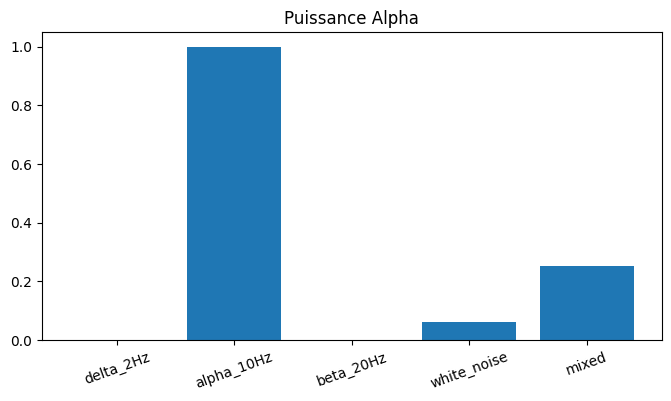

In [ ]:


results = []


for signal_name, signal in synthetic_signals.items():

    features = extract_eeg_features(signal, FS)

    results.append({

        "signal": signal_name,

        "alpha_power":
        features.get("alpha_absolute_power", 0),

        "beta_power":
        features.get("beta_absolute_power", 0),

        "alpha_entropy":
        features.get("alpha_spectral_entropy", 0),

        "hjorth_complexity":
        features.get("hjorth_complexity", 0),

        "higuchi_fd":
        features.get("higuchi_fd", 0),

        "lz_complexity":
        features.get("lempel_ziv_complexity", 0),
    })


results_df = pd.DataFrame(results)


print(results_df)

plt.figure(figsize=(8,4))

plt.bar(results_df["signal"], results_df["alpha_power"])

plt.title("Puissance Alpha")

plt.xticks(rotation=20)

plt.show()

## 12. Application aux signaux EEG du dataset CL-Drive

Après les tests pédagogiques, les mêmes fonctions doivent être appliquées aux signaux EEG prétraités.

### Hypothèse de structure des fichiers

On suppose que les fichiers EEG prétraités sont des fichiers CSV contenant :

- une colonne `Timestamp` ;
- une colonne par canal EEG, par exemple `AF7`, `AF8`, `TP9`, `TP10`.

Exemple de structure :

| Timestamp | AF7 | AF8 | TP9 | TP10 |
|---:|---:|---:|---:|---:|
| 0.000 | ... | ... | ... | ... |
| 0.004 | ... | ... | ... | ... |

### Algorithme d'extraction sur un fichier

1. lire le fichier CSV avec `pd.read_csv` ;
2. identifier les colonnes EEG ;
3. découper le signal en fenêtres de 10 secondes ;
4. pour chaque fenêtre :
   - extraire les 2560 échantillons ;
   - pour chaque canal, calculer les 40 features ;
   - stocker les métadonnées : sujet, fichier, fenêtre, temps début, temps fin, canal ;
5. construire un `DataFrame` ;
6. sauvegarder le résultat en CSV.

### Question

Pourquoi faut-il conserver les colonnes `Participant`, `File`, `Window`, `Channel`, `Start_Time` et `End_Time` avec les features ?

Ces informations permettent de retrouver facilement l'origine de chaque feature et d'associer chaque fenêtre au bon participant et au bon label.

In [ ]:


def extract_features_from_dataframe(
    df,
    participant_id,
    file_name,
    fs=256,
    window_sec=10
):

    eeg_channels = ["AF7", "AF8", "TP9", "TP10"]

    window_samples = fs * window_sec

    all_features = []


    n_windows = len(df) // window_samples

    for w in range(n_windows):

        start = w * window_samples
        end = start + window_samples

        window_df = df.iloc[start:end]

        start_time = window_df["Timestamp"].iloc[0]
        end_time = window_df["Timestamp"].iloc[-1]


        for channel in eeg_channels:

            signal = window_df[channel].values


            features = extract_eeg_features(signal, fs)

            features["Participant"] = participant_id
            features["File"] = file_name
            features["Window"] = w
            features["Channel"] = channel
            features["Start_Time"] = start_time
            features["End_Time"] = end_time

            all_features.append(features)


    features_df = pd.DataFrame(all_features)

    return features_df

## 13. Traitement par lot des fichiers EEG prétraités

Dans le projet, les fichiers prétraités peuvent être organisés par sujet.

Exemple :

```text
Data/
|----EEG/
    ├── Participant_ID1/
    │   ├── filtered_scenario_1.csv
    │   ├── filtered_scenario_2.csv
    │   └── ...
    ├── Participant_ID2/
    │   └── ...
|----EDA
|----ECG
|----Gaze
|----Labels
```

### Algorithme par lot

1. parcourir les dossiers sujets ;
2. sélectionner uniquement les fichiers `filtered_*.csv` ;
3. lire chaque fichier ;
4. extraire les features fenêtre par fenêtre ;
6. sauvegarder un fichier CSV de features par sujet.

### Remarque importante

Les labels PAAS ne se trouvent pas dans le même fichier que les signaux. Une étape d’association entre les features et les labels est donc nécessaire dans un second temps : il faut relier les scores de charge cognitive aux intervalles temporels correspondants.

In [ ]:


import os
import pandas as pd



def batch_extract_eeg_features(
    base_path="/content/Data/EEG",
    output_path="/content/Data/EEG_Features_10s",
    fs=256,
    window_sec=10
):

    os.makedirs(output_path, exist_ok=True)

    for participant_folder in os.listdir(base_path):

        participant_path = os.path.join(base_path, participant_folder)

        if not os.path.isdir(participant_path):
            continue

        print(f"\nTraitement participant : {participant_folder}")

        participant_features = []

        for file_name in os.listdir(participant_path):


            if not file_name.startswith("eeg_data_level_"):
                continue

            if not file_name.endswith(".csv"):
                continue

            file_path = os.path.join(participant_path, file_name)

            print(f"  Lecture fichier : {file_name}")

            df = pd.read_csv(file_path)

            features_df = extract_features_from_dataframe(
                df=df,
                participant_id=participant_folder,
                file_name=file_name,
                fs=fs,
                window_sec=window_sec
            )

            participant_features.append(features_df)

        if len(participant_features) > 0:

            final_df = pd.concat(participant_features, ignore_index=True)

            output_file = os.path.join(
                output_path,
                f"{participant_folder}_features.csv"
            )

            final_df.to_csv(output_file, index=False)

            print(f"  Sauvegardé : {output_file}")

        else:
            print("  Aucun fichier EEG trouvé pour ce participant.")



batch_extract_eeg_features(
    base_path="/content/Data/EEG",
    output_path="/content/Data/EEG_Features_10s",
    fs=256,
    window_sec=10
)


Traitement participant : 1717
  Lecture fichier : eeg_data_level_1.csv
  Lecture fichier : eeg_data_level_3.csv
  Lecture fichier : eeg_data_level_2.csv
  Lecture fichier : eeg_data_level_4.csv
  Lecture fichier : eeg_data_level_5.csv
  Lecture fichier : eeg_data_level_8.csv
  Lecture fichier : eeg_data_level_9.csv
  Lecture fichier : eeg_data_level_6.csv
  Lecture fichier : eeg_data_level_7.csv
  Sauvegardé : /content/Data/EEG_Features_10s/1717_features.csv

Traitement participant : 1744
  Lecture fichier : eeg_data_level_1.csv
  Lecture fichier : eeg_data_level_3.csv
  Lecture fichier : eeg_data_level_2.csv
  Lecture fichier : eeg_data_level_4.csv
  Lecture fichier : eeg_data_level_5.csv
  Lecture fichier : eeg_data_level_6.csv
  Sauvegardé : /content/Data/EEG_Features_10s/1744_features.csv

Traitement participant : 1434
  Lecture fichier : eeg_data_level_1.csv
  Lecture fichier : eeg_data_level_3.csv
  Lecture fichier : eeg_data_level_2.csv
  Lecture fichier : eeg_data_level_4.csv


## 14. Vérifications qualité des features

Avant de passer à la classification, il faut vérifier la qualité de la matrice de features.

### Vérifications recommandées

1. nombre de lignes cohérent avec le nombre de fenêtres et de canaux ;
2. absence de valeurs manquantes ;
3. absence de valeurs infinies ;
4. ordre de grandeur plausible ;
5. nombre de features égal à 40 par canal ;
6. conservation des métadonnées utiles ;
7. possibilité d'associer ensuite chaque fenêtre à un label.

### Questions

1. Pourquoi des valeurs `NaN` peuvent-elles apparaître dans les features ?
2. Pourquoi des valeurs infinies peuvent-elles apparaître ?
3. Que doit-on faire si un segment contient trop de valeurs manquantes ?
4. Pourquoi faut-il éviter de normaliser les features avant la séparation train/test ?

### Réponses

1. Parce qu'il peut manquer des données ou qu'un calcul est impossible sur certains segments.

2. À cause d'une division par zéro ou d'un calcul de logarithme invalide.

3. Il vaut mieux supprimer ce segment plutôt que d'utiliser des données incorrectes.

4. Pour éviter que les informations du jeu de test influencent le jeu d'entraînement et faussent les résultats.

In [ ]:


import pandas as pd
import numpy as np

def check_features_quality(features_df):

    print("===== CONTRÔLE QUALITÉ =====")


    print("Nombre de lignes :", features_df.shape[0])
    print("Nombre de colonnes :", features_df.shape[1])


    n_nan = features_df.isna().sum().sum()
    print("Nombre de valeurs NaN :", n_nan)


    numeric_df = features_df.select_dtypes(include=[np.number])
    n_inf = np.isinf(numeric_df).sum().sum()
    print("Nombre de valeurs infinies :", n_inf)


    metadata_cols = [
        "Participant",
        "File",
        "Window",
        "Channel",
        "Start_Time",
        "End_Time"
    ]

    print("\nMétadonnées :")
    for col in metadata_cols:
        if col in features_df.columns:
            print(col, ": OK")
        else:
            print(col, ": MANQUANTE")


    feature_cols = [
        col for col in features_df.columns
        if col not in metadata_cols
    ]

    print("\nNombre de features :", len(feature_cols))

    if len(feature_cols) == 40:
        print("Nombre de features OK : 40")
    else:
        print("Attention : nombre de features différent de 40")


    print("\nStatistiques des features numériques :")
    print(numeric_df.describe())

    print("\n===== FIN CONTRÔLE =====")




features_path = "/content/Data/EEG_Features_10s/1030_features.csv"

features_df = pd.read_csv(features_path)

check_features_quality(features_df)

===== CONTRÔLE QUALITÉ =====
Nombre de lignes : 640
Nombre de colonnes : 46
Nombre de valeurs NaN : 0
Nombre de valeurs infinies : 0

Métadonnées :
Participant : OK
File : OK
Window : OK
Channel : OK
Start_Time : OK
End_Time : OK

Nombre de features : 40
Nombre de features OK : 40

Statistiques des features numériques :
       delta_absolute_power  delta_mean_power  delta_max_power  \
count            640.000000        640.000000       640.000000   
mean            1938.726153        276.960879       547.117608   
std             3910.032869        558.576124      1216.320792   
min               20.105539          2.872220         4.423886   
25%              211.826200         30.260886        67.472196   
50%              877.470110        125.352873       220.882751   
75%             2248.755411        321.250773       528.039658   
max            62323.837064       8903.405295     22744.006646   

       delta_min_power  delta_median_power  theta_absolute_power  \
count       640

In [ ]:
import shutil


source_dir = '/content/Data'


output_archive_name = '/content/Data'


shutil.make_archive(output_archive_name, 'zip', source_dir)

print(f"Directory '{source_dir}' compressed to '{output_archive_name}.zip'")

Directory '/content/Data' compressed to '/content/Data.zip'
